In [1]:
import sys, os, json, importlib
sys.path.insert(0, '..')

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import dt.model, dt.dataset, dt.evaluate
importlib.reload(dt.model)
importlib.reload(dt.dataset)
importlib.reload(dt.evaluate)

from dt.model    import DecisionTransformer
from dt.dataset  import SequenceDataset
from dt.evaluate import evaluate_dt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')
if device.type == 'cuda':
    print(f'  {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

c:\GitHub\Skoltech courses\DL\project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
  NVIDIA GeForce RTX 4050 Laptop GPU
  VRAM: 6.4 GB


In [2]:
import torch
print(f'torch version : {torch.__version__}')
print(f'CUDA built    : {torch.version.cuda}')
print(f'CUDA available: {torch.cuda.is_available()}')
if not torch.cuda.is_available():
    print()
    print('Диагноз: PyTorch скорее всего установлен без CUDA.')
    print('Переустановить:')
    print('  pip install torch --index-url https://download.pytorch.org/whl/cu124')

torch version : 2.6.0+cu124
CUDA built    : 12.4
CUDA available: True


In [3]:
# --- config ---
DATA_DIR     = '../data'
CKPT_DIR     = '../checkpoints'
RESULTS_FILE = '../results.json'
os.makedirs(CKPT_DIR, exist_ok=True)

MODEL_CFG = dict(
    obs_dim      = 3,
    act_dim      = 2,
    embed_dim    = 64,
    n_heads      = 4,
    n_layers     = 3,
    dropout      = 0.1,
    context_len  = 20,
    max_timestep = 1000,
)

TRAIN_CFG = dict(
    batch_size       = 1024,
    samples_per_traj = 20,
    n_epochs         = 50,
    lr               = 1e-3,
    weight_decay     = 1e-4,
    val_every        = 5,
    n_eval_eps       = 30,
    desired_rtg      = -0.4,
)

DATASETS = ['1k', '2k', '5k', '10k']

In [4]:
def train_one(dataset_key, model_cfg, train_cfg, device):
    h5_path = f"{DATA_DIR}/dataset_{dataset_key}.h5"
    print(f'\n=== Dataset: {dataset_key} ===')

    dataset = SequenceDataset(
        h5_path,
        context_len      = model_cfg['context_len'],
        samples_per_traj = train_cfg['samples_per_traj'],
    )
    loader = DataLoader(
        dataset,
        batch_size = train_cfg['batch_size'],
        shuffle    = True,
        num_workers = 0,
        pin_memory  = True,
    )
    print(f'  samples: {len(dataset)}  batches/epoch: {len(loader)}')
    print(f'  rtg_scale={dataset.rtg_scale:.1f}')

    model = DecisionTransformer(**model_cfg).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=train_cfg['lr'], weight_decay=train_cfg['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=train_cfg['n_epochs']
    )
    scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))


    history   = {'train_loss': [], 'success_rate': [], 'mean_length': []}
    best_loss = float('inf')
    ckpt_path = f"{CKPT_DIR}/dt_{dataset_key}_best.pt"

    epoch_bar = tqdm(range(1, train_cfg['n_epochs'] + 1), desc=dataset_key)
    for epoch in epoch_bar:
        model.train()
        epoch_loss = 0.0

        for batch in loader:
            obs       = batch['obs'].to(device, non_blocking=True)
            actions   = batch['actions'].to(device, non_blocking=True)
            rtg       = batch['rtg'].to(device, non_blocking=True)
            timesteps = batch['timesteps'].to(device, non_blocking=True)

            with torch.autocast(device.type, enabled=(device.type == 'cuda')):
                pred = model(obs, actions, rtg, timesteps)
                loss = F.mse_loss(pred, actions)

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += loss.item()

        scheduler.step()
        avg_loss = epoch_loss / len(loader)
        history['train_loss'].append(avg_loss)

        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), ckpt_path)

        if epoch % train_cfg['val_every'] == 0:
            metrics = evaluate_dt(
                model, dataset, device,
                n_episodes  = train_cfg['n_eval_eps'],
                desired_rtg = train_cfg['desired_rtg'],
            )
            history['success_rate'].append(metrics['success_rate'])
            history['mean_length'].append(metrics['mean_length'])
            epoch_bar.set_postfix(
                loss=f'{avg_loss:.4f}',
                sr=f"{metrics['success_rate']:.2%}",
                ml=f"{metrics['mean_length']:.0f}"
            )
        else:
            epoch_bar.set_postfix(loss=f'{avg_loss:.4f}')

    return history

In [5]:
results = {}

for key in DATASETS:
    results[key] = train_one(key, MODEL_CFG, TRAIN_CFG, device)
    with open(RESULTS_FILE, 'w') as f:
        json.dump(results, f, indent=2)
    print(f'Saved → {RESULTS_FILE} (done: {key})')

print('All datasets done.')


=== Dataset: 1k ===
  samples: 20000  batches/epoch: 20
  rtg_scale=542.0


c:\GitHub\Skoltech courses\DL\project\.venv\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
1k: 100%|██████████| 50/50 [03:49<00:00,  4.59s/it, loss=0.0343, ml=253, sr=100.00%]


Saved → ../results.json (done: 1k)

=== Dataset: 2k ===


c:\GitHub\Skoltech courses\DL\project\.venv\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  samples: 40000  batches/epoch: 40
  rtg_scale=542.0


...

Saved → ../results.json (done: 2k)

=== Dataset: 5k ===
  samples: 100000  batches/epoch: 98
  rtg_scale=668.6


5k: 100%|██████████| 50/50 [07:55<00:00,  9.52s/it, loss=0.0151, ml=449, sr=100.00%]


Saved → ../results.json (done: 5k)

=== Dataset: 10k ===
  samples: 200000  batches/epoch: 196
  rtg_scale=741.1


10k: 100%|██████████| 50/50 [14:23<00:00, 17.28s/it, loss=0.0124, ml=272, sr=100.00%]

Saved → ../results.json (done: 10k)
All datasets done.


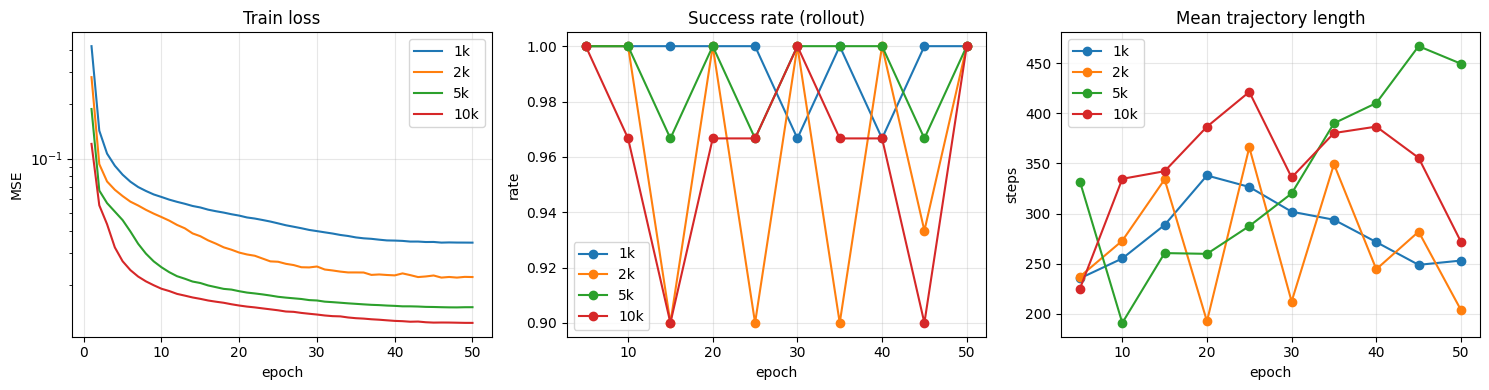

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['C0', 'C1', 'C2', 'C3']

for (key, hist), color in zip(results.items(), colors):
    epochs = range(1, len(hist['train_loss']) + 1)
    axes[0].plot(epochs, hist['train_loss'], label=key, color=color)
    axes[0].set_yscale('log')

    val_epochs = range(TRAIN_CFG['val_every'], TRAIN_CFG['n_epochs'] + 1, TRAIN_CFG['val_every'])
    axes[1].plot(list(val_epochs)[:len(hist['success_rate'])], hist['success_rate'],
                 marker='o', label=key, color=color)
    axes[2].plot(list(val_epochs)[:len(hist['mean_length'])], hist['mean_length'],
                 marker='o', label=key, color=color)

axes[0].set(title='Train loss', xlabel='epoch', ylabel='MSE')
axes[1].set(title='Success rate (rollout)', xlabel='epoch', ylabel='rate')
axes[2].set(title='Mean trajectory length', xlabel='epoch', ylabel='steps')

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results.png', dpi=120)
plt.show()